In [73]:
import datetime
import sklearn
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import MinMaxScaler,MaxAbsScaler
from sklearn.decomposition import KernelPCA
import numpy as np
import pandas as pd
import math
import keras
import matplotlib.pyplot as plt
import tensorflow as tf
from keras.callbacks import EarlyStopping
from keras.callbacks import EarlyStopping
from keras.optimizers import Adam
from keras.layers import Attention

tf.random.set_seed(666)


In [74]:
# Single step dataset preparation
def singleStepSampler(df, window):
	xRes = []
	yRes = []
	for i in range(0, len(df) - window):
		res = []
		for j in range(0, window):
			r = []
			for col in df.columns:
				r.append(df[col][i + j])
			res.append(r)
		xRes.append(res)
		yRes.append(df[['dis']].iloc[i + window].values)
	return np.array(xRes), np.array(yRes)


In [75]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [109]:
# Dataset loading
name = '2_dsk_imputMF_month'
csv_path = f"/content/drive/MyDrive/river_runoff_obs/{name}.csv"
usecols = ['time', 'pre', 'tm', 'tmax', 'tmin',  'dis']
dataFrame_full = pd.read_csv(csv_path, usecols=usecols)
# this refers to observed runoff and 10d_mean refers to the runoff with MA

In [110]:
dataFrame_full

,time,pre,tm,tmax,tmin,dis
0,1962/1/31,3.825191,-16.279079,-9.028803,-23.318657,1673.5
1,1962/2/28,1.133750,-10.342336,-2.056426,-18.615003,1272.8
2,1962/3/31,0.496654,-0.919789,6.945637,-8.755629,1797.6
3,1962/4/30,3.280110,5.594456,12.808561,-1.829409,2876.3
4,1962/5/31,12.361218,13.759641,20.330606,6.567921,3124.6
...,...,...,...,...,...,...
727,2022/8/31,49.401191,16.543764,22.657443,10.980731,NaN
728,2022/9/30,10.030288,14.222144,22.359197,6.345373,NaN
729,2022/10/31,3.101481,4.225551,12.021601,-2.610393,NaN
730,2022/11/30,0.953780,-3.533379,3.721456,-9.663413,NaN


In [111]:
# Get Index of NaN Values in a Specific Column:

# Create a boolean series that identifies NaN values
is_null = dataFrame_full['dis'].isnull()


# Shift the boolean series to identify changes between NaN and non-NaN values
shifted = is_null.ne(is_null.shift()).cumsum()

# Group by the shifted series and filter to only NaN sections
nan_sections = dataFrame_full[is_null].groupby(shifted)

# Extract the start and end indices for each section and create separate lists for them
start_indices = []
end_indices = []

for _, group in nan_sections:
    start_indices.append(group.index[0])
    end_indices.append(group.index[-1])

# Create a DataFrame from the lists
null_index_df = pd.DataFrame({'Start': start_indices, 'End': end_indices})

In [112]:
null_index_df

,Start,End
0,684,731


In [113]:
def intercept_data(i):
	global dataFrame
	# Intercept the first section of missing value
	# dataFrame = dataFrame_full[ :null_index_df["End"][i]+365]
	dataFrame = dataFrame_full[ :null_index_df["End"][i]+1]

In [114]:
def scaler_data(dataFrame ):
	global scaler
	imputer = SimpleImputer(missing_values=np.nan) # Handling missing values
	if 'time' in dataFrame.columns:
		dataFrame.drop(columns=['time'], inplace=True)
	dataFrame = pd.DataFrame(imputer.fit_transform(dataFrame), columns=dataFrame.columns)
	dataFrame = dataFrame.reset_index(drop=True)
	# Applying feature scaling
	scaler = MinMaxScaler(feature_range=(0, 1))
	df_scaled = scaler.fit_transform(dataFrame.to_numpy())
	df_scaled = pd.DataFrame(df_scaled, columns=list(dataFrame.columns))
	target_scaler = MinMaxScaler(feature_range=(0, 1))
	df_scaled[ ['dis']] = target_scaler.fit_transform(dataFrame[ ['dis']].to_numpy())
	df_scaled = df_scaled.astype(float)

	return df_scaled

In [115]:
# def scaler_data(dataFrame):
#     global scaler
#
#     # Handling missing values with SimpleImputer
#     imputer = SimpleImputer(missing_values=np.nan, strategy='mean')
#     if 'time' in dataFrame.columns:
#         dataFrame.drop(columns=['time'], inplace=True)
#
#     # Impute missing values
#     dataFrame = pd.DataFrame(imputer.fit_transform(dataFrame), columns=dataFrame.columns)
#     dataFrame = dataFrame.reset_index(drop=True)
#
#     # Separate features and target (assuming 'dis' is the target)
#     features = dataFrame.drop(columns=['dis'])
#     target = dataFrame[['dis']]
#
#     # Apply MaxAbsScaler to features
#     scaler = MaxAbsScaler()
#     features_scaled = scaler.fit_transform(features)
#
#     # Apply MinMaxScaler to the target column ('dis')
#     target_scaler = MinMaxScaler(feature_range=(0, 1))
#     target_scaled = target_scaler.fit_transform(target)
#
#     # Combine the scaled features and target back into a DataFrame
#     df_scaled = pd.DataFrame(features_scaled, columns=features.columns)
#     df_scaled['dis'] = target_scaled  # Add the scaled target back
#
#     # Ensure all values are float type
#     df_scaled = df_scaled.astype(float)
#
#     return df_scaled

In [116]:
## Data spliting

In [117]:
def split_data(df_scaled ,i):

	# Dataset splitting
	SPLIT = 0.7 # Equal to the rate by Pr. Wang Lei train_data_rate = 0.7

	(xVal, yVal) = singleStepSampler(df_scaled, time_step)
	X_train =    xVal[:int(SPLIT * len(xVal))]
	y_train =    yVal[:int(SPLIT * len(yVal))]
	X_test =     xVal[int(SPLIT * len(xVal)):]
	y_test =     yVal[int(SPLIT * len(yVal)):]

	X_forecast = xVal[null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] # For singleStepSampler, the time step need to be added.
	# X_forecast = xVal[:] # We will use the whole dataset for forecast
	yVal[null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] = 0
	"""Whether or not as the following"""
	# X_forecast = xVal[null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] # For singleStepSampler, the time step need to be added.

	return X_train, y_train, X_test, y_test ,X_forecast

In [118]:
# X_train, y_train, X_test, y_test , X_forecast = split_data(df_scaled,i)

In [119]:
# null_index_df["Start"][0] - null_index_df["End"][0]

In [120]:
def model_building(X_train):
	multivariate_lstm = keras.Sequential()
	multivariate_lstm.add(keras.layers.LSTM(200, input_shape=(X_train.shape[1], X_train.shape[2])))
	multivariate_lstm.add(keras.layers.Dropout(0.4))
	multivariate_lstm.add(keras.layers.Dense(1, activation='linear')) # Only output the ET
	multivariate_lstm.compile(loss = 'MeanSquaredError', metrics=['MAE'], optimizer='Adam')
	multivariate_lstm.summary()
	return multivariate_lstm

In [121]:
# def model_building(X_train):
# 	multivariate_lstm = keras.Sequential()
# 	multivariate_lstm.add(keras.layers.LSTM(200, input_shape=(X_train.shape[1], X_train.shape[2])))
# 	multivariate_lstm.add(keras.layers.Dropout(0.4))
# 	multivariate_lstm.add(keras.layers.Dense(50, activation='linear')) # Only output the ET
# 	multivariate_lstm.compile(loss = 'MeanSquaredError', metrics=['MAE'], optimizer='Adam')
# 	multivariate_lstm.summary()
#
# 	# Early stopping callback
# 	early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
# 	return multivariate_lstm

In [122]:
# """use bidirectional LSTM"""
# from keras.layers import Bidirectional
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#
#     # Add a bidirectional LSTM layer
#     multivariate_lstm.add(Bidirectional(keras.layers.LSTM(200, return_sequences=False), input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     multivariate_lstm.add(keras.layers.Dense(100, activation='relu'))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))  # Final output
#
#     # Compile the model
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     multivariate_lstm.summary()
#
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#     return multivariate_lstm

In [123]:
# from keras.models import Sequential
# from keras.layers import Conv1D, MaxPooling1D, Bidirectional, LSTM, Dropout, Dense, Flatten
# from keras.optimizers import Adam
# from keras.callbacks import EarlyStopping
# from bayes_opt import BayesianOptimization
# import numpy as np
#
# def model_building(X_train):
#     model = Sequential()
#
#     # Add 1D Convolutional layers for feature extraction
#     model.add(Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
#     model.add(MaxPooling1D(pool_size=2))
#
#     # Add Bi-directional LSTM layer for temporal dependencies
#     model.add(Bidirectional(LSTM(200, return_sequences=False)))
#
#     # Dropout layer for regularization
#     model.add(Dropout(0.4))
#
#     # Dense layers for further learning
#     model.add(Dense(100, activation='relu'))
#     model.add(Dense(50, activation='linear'))  # Output layer for runoff forecast
#
#     # Compile the model
#     model.compile(optimizer=Adam(), loss='MeanSquaredError', metrics=['MAE'])
#
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#
#     model.summary()
#     return model
#
# # VMD Step
# def vmd_decomposition(data):
#     # Perform Variational Mode Decomposition (VMD) here
#     # This will output multiple decomposed signals that can be used as input features
#     decomposed_modes = []  # Placeholder for decomposed signals
#     # Implement VMD decomposition here, or use a library
#     return np.array(decomposed_modes)
#
# # Bayes Optimization for hyperparameter tuning
# def optimize_model(X_train, y_train):
#     def model_evaluate(lstm_units, dropout_rate, conv_filters):
#         model = Sequential()
#
#         # CNN layers
#         model.add(Conv1D(filters=int(conv_filters), kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
#         model.add(MaxPooling1D(pool_size=2))
#
#         # BiLSTM layer
#         model.add(Bidirectional(LSTM(int(lstm_units), return_sequences=False)))
#
#         # Dropout layer
#         model.add(Dropout(dropout_rate))
#
#         # Dense layers
#         model.add(Dense(100, activation='relu'))
#         model.add(Dense(50, activation='linear'))  # Output layer
#
#         # Compile the model
#         model.compile(optimizer=Adam(), loss='MeanSquaredError', metrics=['MAE'])
#
#         # Train and evaluate the model
#         model.fit(X_train, y_train, epochs=10, batch_size=32, verbose=0)  # Dummy training for optimization purposes
#
#         # Evaluation metric (can be MAE or validation loss)
#         mae = model.evaluate(X_train, y_train, verbose=0)[1]
#         return -mae  # Minimize the MAE (or other metric)
#
#     # Define the parameter space for Bayes Optimization
#     pbounds = {
#         'lstm_units': (50, 300),
#         'dropout_rate': (0.2, 0.5),
#         'conv_filters': (32, 128)
#     }
#
#     optimizer = BayesianOptimization(
#         f=model_evaluate,
#         pbounds=pbounds,
#         random_state=42
#     )
#
#     optimizer.maximize(init_points=10, n_iter=50)
#
#     best_params = optimizer.max['params']
#     return best_params
#
# # Example usage
# # X_train and y_train should be the processed and decomposed data
# X_train_decomposed = vmd_decomposition(X_train)  # Apply VMD
# best_params = optimize_model(X_train_decomposed, y_train)  # Optimize the model with BOA
#
# # Build the final model with best parameters found by BOA
# final_model = model_building(X_train_decomposed)


In [124]:
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#     # Add more layers or units to increase capacity
#     multivariate_lstm.add(keras.layers.LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.LSTM(128))
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     # Add additional dense layers
#     multivariate_lstm.add(keras.layers.Dense(100, activation='relu'))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))  # Final output layer
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     multivariate_lstm.summary()
#
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#     return multivariate_lstm


In [125]:
# # model source https://www.nature.com/articles/s41598-024-63989-7#Sec2
# import tensorflow as tf
# from tensorflow.keras import layers, models
#
# def model_building(X_train):
#     multivariate_lstm = models.Sequential()
#
#     # First LSTM layer with 512 neurons and ReLU activation
#     multivariate_lstm.add(layers.LSTM(units=512, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Second LSTM layer with a progressive reduction in neurons
#     multivariate_lstm.add(layers.LSTM(units=256, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Third LSTM layer with further reduction in neurons
#     multivariate_lstm.add(layers.LSTM(units=128, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Fourth LSTM layer with 64 neurons
#     multivariate_lstm.add(layers.LSTM(units=64, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Fifth LSTM layer with 32 neurons
#     multivariate_lstm.add(layers.LSTM(units=32, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Sixth LSTM layer with 16 neurons
#     multivariate_lstm.add(layers.LSTM(units=16, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Seventh LSTM layer with 8 neurons
#     multivariate_lstm.add(layers.LSTM(units=8, return_sequences=True))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Eighth LSTM layer with 4 neurons
#     multivariate_lstm.add(layers.LSTM(units=4, return_sequences=False))
#     multivariate_lstm.add(layers.Activation('relu'))
#     multivariate_lstm.add(layers.Dropout(0.5))
#
#     # Output layer with 1 neuron for the prediction of runoff
#     multivariate_lstm.add(layers.Dense(units=1))
#
#     # Compile the model using Adam optimizer and MSE as loss function
#     optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)
#     multivariate_lstm.compile(optimizer=optimizer, loss='mean_squared_error')
#
#     return multivariate_lstm


In [126]:
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#
#     # LSTM layer
#     multivariate_lstm.add(keras.layers.LSTM(200, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#
#     # Attention mechanism
#     attention = Attention()
#     multivariate_lstm.add(attention)
#
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))
#
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     multivariate_lstm.summary()
#
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#     return multivariate_lstm

In [127]:
# """Add CNN Layer"""
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#
#     # Add a CNN layer
#     multivariate_lstm.add(keras.layers.Conv1D(filters=64, kernel_size=3, activation='relu', input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.MaxPooling1D(pool_size=2))
#
#     # Add LSTM layers
#     multivariate_lstm.add(keras.layers.LSTM(200, return_sequences=True))
#     multivariate_lstm.add(keras.layers.LSTM(150))
#
#     multivariate_lstm.add(keras.layers.Dropout(0.4))
#     multivariate_lstm.add(keras.layers.Dense(250, activation='linear'))
#
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer='Adam')
#     return multivariate_lstm

In [128]:
# def model_building(X_train):
#     multivariate_lstm = keras.Sequential()
#
#     # LSTM layers with increased capacity
#     multivariate_lstm.add(keras.layers.LSTM(256, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
#     multivariate_lstm.add(keras.layers.LSTM(128))
#
#     # Dropout for regularization
#     multivariate_lstm.add(keras.layers.Dropout(0.5))
#
#     # Add dense layers for better learning
#     multivariate_lstm.add(keras.layers.Dense(100, activation='relu'))
#     multivariate_lstm.add(keras.layers.Dense(50, activation='linear'))  # Final output
#
#     # Compile the model with an adjusted learning rate
#     optimizer = Adam(learning_rate=0.001)
#     multivariate_lstm.compile(loss='MeanSquaredError', metrics=['MAE'], optimizer=optimizer)
#     multivariate_lstm.summary()
#
#     # Early stopping callback
#     early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
#
#     return multivariate_lstm

In [129]:
# # Model training
# def model_training(multivariate_lstm,X_train, y_train, X_test, y_test):
# 	history = multivariate_lstm.fit(X_train, y_train, epochs= 1000)
# 	return multivariate_lstm

In [130]:
def model_training(multivariate_lstm, X_train, y_train, X_test, y_test):
    # Define early stopping to avoid overfitting
    early_stopping = tf.keras.callbacks.EarlyStopping(
        monitor='val_loss', patience=50, restore_best_weights=True)

    # Train the model
    history = multivariate_lstm.fit(
        X_train, y_train,
        epochs=1000,
        batch_size=128,
        validation_data=(X_test, y_test),
        callbacks=[early_stopping],
        verbose=1  # Optional, to display training progress
    )

    # Return both the trained model and the training history
    return multivariate_lstm, history


In [131]:
# def medel_predict(multivariate_lstm,  X_test, y_test):
# 	global predicted_values,X_test_predicted_df
#
# 	dataFrame = dataFrame_full[ :null_index_df["End"][i]]# Assuming the CSV file contains a 'Date' column
# 	# dataFrame['time'] = pd.to_datetime(dataFrame['time'])
# 	dataFrame.set_index('time', inplace=True)
#
# 	# Forecast Plot with Dates on X-axis
# 	predicted_values = multivariate_lstm.predict(X_test)
#
# 	d = {
# 		'Actual_runoff': y_test.ravel(),
# 		'Predicted_runoff': predicted_values.ravel()
# 	}
# 	d = pd.DataFrame(d)
# 	d.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.csv")
# 	return d

In [132]:
def medel_predict(multivariate_lstm,  X_test, y_test):
	global predicted_values,X_test_predicted_df

	dataFrame = dataFrame_full[ :null_index_df["End"][i]]# Assuming the CSV file contains a 'Date' column
	# dataFrame['time'] = pd.to_datetime(dataFrame['time'])
	dataFrame.set_index('time', inplace=True)

	# Forecast Plot with Dates on X-axis
	predicted_values = multivariate_lstm.predict(X_test)

	if len(predicted_values.shape)== 1 or predicted_values.shape[-1] == 1:
		d = {
		'Actual_runoff': y_test.ravel(),
		'Predicted_runoff': predicted_values.ravel()
	}
	else:
		d = {
		'Actual_runoff': y_test.ravel(),
		'Predicted_runoff': predicted_values[:,time_step-1]
	}
	d = pd.DataFrame(d)
	d.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_test{i}.csv")
	return d

In [133]:
	# d=medel_predict(multivariate_lstm,  X_test, y_test)


In [134]:
# def forecast_model(multivariate_lstm,X_forecast):
# 	global forecast_df,forecast_values,forecast_arr
# 	forecast_values = multivariate_lstm.predict(X_forecast)
# 	# print(X_forecast[:,time_step-1,:4].shape,forecast_values[:,time_step-1].reshape(-1, 1).shape )
# 	forecast_arr = np.concatenate((X_forecast[:,time_step-1,:X_train.shape[-1] - 1],forecast_values ), axis=1)
# 	forecast_inversed = scaler.inverse_transform(forecast_arr)
#
# 	forecast_df = pd.DataFrame(forecast_inversed, columns=usecols[1:])
# 	# forecast_df = pd.DataFrame(pd.concat([X_forecast, forecast_values], axis=1), columns=usecols[1:])
# 	dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][null_index_df["Start"][i]-time_step  :null_index_df["End"][i]+1] ###
# 	dataFrame_full.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_interpolated{i}.csv")
# 	forecast_df.to_csv(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.csv")
# 	forecast_df.plot()
# 	plt.savefig(f"F:\\geodata\\river_runoff_obs\\{name}_{time_step}_test{i}.svg")
# 	plt.show()
# 	return forecast_df
#


In [135]:
def forecast_model(multivariate_lstm,X_forecast):
	global forecast_df,forecast_values,forecast_arr
	forecast_values = multivariate_lstm.predict(X_forecast)
	# print(X_forecast[:,time_step-1,:X_train.shape[-1] - 1].shape,forecast_values[:,time_step-1].reshape(-1, 1).shape )
	if len(forecast_values.shape) == 1 or forecast_values.shape[-1] == 1:
		forecast_arr = np.concatenate((X_forecast[:,time_step-1,:X_train.shape[-1]-1],forecast_values[:].reshape(-1, 1) ), axis=1)
	else:
		forecast_arr = np.concatenate((X_forecast[:,time_step-1,:X_train.shape[-1]-1],forecast_values[:,time_step-1].reshape(-1, 1) ), axis=1)

	forecast_inversed = scaler.inverse_transform(forecast_arr)

	forecast_df = pd.DataFrame(forecast_inversed, columns=usecols[1:])
	# forecast_df = pd.DataFrame(pd.concat([X_forecast, forecast_values], axis=1), columns=usecols)
	dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###
	dataFrame_full.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_interpolated{i}.csv")
	forecast_df.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_forecast{i}.csv")
	forecast_df.plot()
	plt.title(f'{name} at the time step {time_step}')
	plt.savefig(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_test{i}.jpg")
	plt.show()
	return forecast_df



In [136]:
def model_evaluation(d):

	# Observed and predicted data
	observed = d['Actual_runoff']
	predicted = d['Predicted_runoff']

	# Correlation Coefficient (CC)
	CC = d['Predicted_runoff'].corr(d['Actual_runoff'])

	# Nash-Sutcliffe Efficiency (NSE)
	mean_observed = np.mean(observed)
	NSE = 1 - (np.sum((observed - predicted) ** 2) / np.sum((observed - mean_observed) ** 2))

	# Kling-Gupta Efficiency (KGE)
	mean_predicted = np.mean(predicted)
	std_observed = np.std(observed)
	std_predicted = np.std(predicted)
	r = np.corrcoef(observed, predicted)[0, 1]
	alpha = std_predicted / std_observed
	beta = mean_predicted / mean_observed
	KGE = 1 - np.sqrt((r - 1)**2 + (alpha - 1)**2 + (beta - 1)**2)

	# Root-Mean-Square Error (RMSE)
	RMSE = np.sqrt(np.mean((predicted - observed) ** 2))

	# Mean Absolute Relative Error (MARE)
	MARE = np.mean(np.abs((observed - predicted) / mean_observed))

	# Percent Bias (PBIAS)
	PBIAS = 100 * np.sum(predicted - observed) / np.sum(observed)

	# Coefficient of Determination (R²)
	SS_res = np.sum((observed - predicted) ** 2)
	SS_tot = np.sum((observed - mean_observed) ** 2)
	R2 = 1 - (SS_res / SS_tot)

	# Print all metrics
	print("Correlation Coefficient (CC):", CC)
	print("Nash-Sutcliffe Efficiency (NSE):", NSE)
	print("Kling-Gupta Efficiency (KGE):", KGE)
	print("Root-Mean-Square Error (RMSE):", RMSE)
	print("Mean Absolute Relative Error (MARE):", MARE)
	print("Percent Bias (PBIAS):", PBIAS)
	print("Coefficient of Determination (R²):", R2)

	d.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_test{i}.csv")

	return CC,NSE,KGE,RMSE,MARE,PBIAS,R2

In [137]:
# # d=medel_predict(multivariate_lstm[0],  X_test, y_test)
# forecast_df  = forecast_model(multivariate_lstm[0],X_forecast)

In [138]:
time_step = 80

0


<ipython-input-114-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_22"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_22 (LSTM)                       │ (None, 200)                 │         164,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_22 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_22 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,001 (644.54 KB)

 Trainable params: 165,001 (644.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 74ms/step - MAE: 0.2885 - loss: 0.1252 - val_MAE: 0.2671 - val_loss: 0.0887
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - MAE: 0.2298 - loss: 0.0724 - val_MAE: 0.1685 - val_loss: 0.0381
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - MAE: 0.1625 - loss: 0.0428 - val_MAE: 0.1391 - val_loss: 0.0353
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - MAE: 0.1490 - loss: 0.0456 - val_MAE: 0.1372 - val_loss: 0.0305
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - MAE: 0.1457 - loss: 0.0380 - val_MAE: 0.1531 - val_loss: 0.0314
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - MAE: 0.1478 - loss: 0.0332 - val_MAE: 0.1603 - val_loss: 0.0339
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - MAE: 0.1456 - loss: 0.0325 - val_MAE: 0.1460 - val_loss: 0.0292
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - MAE: 0.1346 - loss: 0.0292 - val_MAE: 0.1267 - val_loss: 0.0246
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step - MAE: 0.1178

<ipython-input-135-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


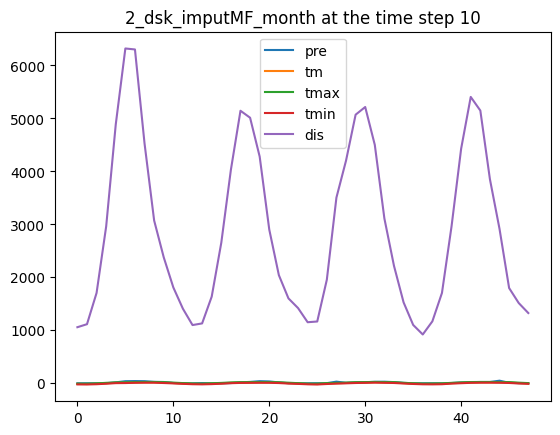

Correlation Coefficient (CC): 0.7231359899959854
Nash-Sutcliffe Efficiency (NSE): 0.49002749678478685
Kling-Gupta Efficiency (KGE): 0.6339749301512874
Root-Mean-Square Error (RMSE): 0.12646258896412402
Mean Absolute Relative Error (MARE): 0.44226793974487494
Percent Bias (PBIAS): 15.042949576431909
Coefficient of Determination (R²): 0.49002749678478685


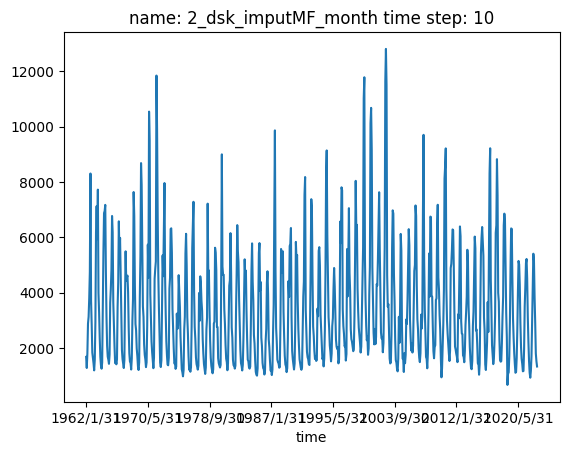

0


<ipython-input-114-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_23 (LSTM)                       │ (None, 200)                 │         164,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_23 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_23 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,001 (644.54 KB)

 Trainable params: 165,001 (644.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - MAE: 0.1938 - loss: 0.0600 - val_MAE: 0.1409 - val_loss: 0.0392
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - MAE: 0.1622 - loss: 0.0532 - val_MAE: 0.1507 - val_loss: 0.0312
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - MAE: 0.1517 - loss: 0.0355 - val_MAE: 0.1717 - val_loss: 0.0382
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - MAE: 0.1488 - loss: 0.0338 - val_MAE: 0.1271 - val_loss: 0.0256
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - MAE: 0.1265 - loss: 0.0316 - val_MAE: 0.1167 - val_loss: 0.0239
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - MAE: 0.1231 - loss: 0.0311 - val_MAE: 0.1312 - val_loss: 0.0254
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step - MAE: 0.1210 - loss: 0.0251 - val_MAE: 0.1326 - val_loss: 0.0259
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - MAE: 0.1145 - loss: 0.0218 - val_MAE: 0.1066 - val_loss: 0.0205
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - MAE: 0.0960

<ipython-input-135-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


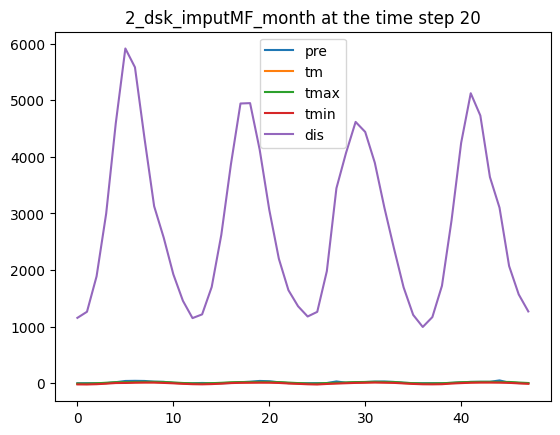

Correlation Coefficient (CC): 0.725600339262875
Nash-Sutcliffe Efficiency (NSE): 0.5095850488400318
Kling-Gupta Efficiency (KGE): 0.5929026246807592
Root-Mean-Square Error (RMSE): 0.12446938717439557
Mean Absolute Relative Error (MARE): 0.4453052358470313
Percent Bias (PBIAS): 12.383874539104132
Coefficient of Determination (R²): 0.5095850488400318


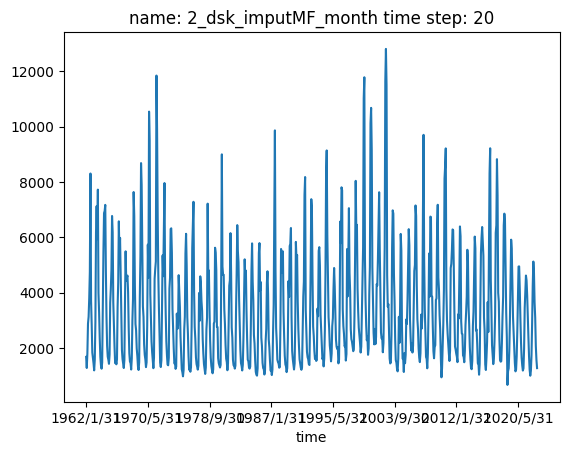

0


<ipython-input-114-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_24"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_24 (LSTM)                       │ (None, 200)                 │         164,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_24 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_24 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,001 (644.54 KB)

 Trainable params: 165,001 (644.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - MAE: 0.1785 - loss: 0.0529 - val_MAE: 0.1435 - val_loss: 0.0309
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.1460 - loss: 0.0392 - val_MAE: 0.1415 - val_loss: 0.0289
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - MAE: 0.1436 - loss: 0.0332 - val_MAE: 0.1545 - val_loss: 0.0320
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.1330 - loss: 0.0287 - val_MAE: 0.1193 - val_loss: 0.0236
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.1137 - loss: 0.0255 - val_MAE: 0.1208 - val_loss: 0.0232
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.1124 - loss: 0.0224 - val_MAE: 0.1152 - val_loss: 0.0223
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - MAE: 0.0933 - loss: 0.0165 - val_MAE: 0.0952 - val_loss: 0.0190
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - MAE: 0.0839 - loss: 0.0155 - val_MAE: 0.0955 - val_loss: 0.0201
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - MAE: 0.0776

<ipython-input-135-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


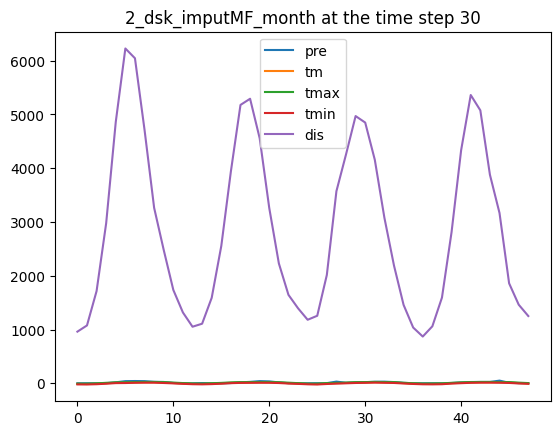

Correlation Coefficient (CC): 0.7163941572330018
Nash-Sutcliffe Efficiency (NSE): 0.49084158598436545
Kling-Gupta Efficiency (KGE): 0.6229399819632946
Root-Mean-Square Error (RMSE): 0.12763359054620305
Mean Absolute Relative Error (MARE): 0.4463435114862838
Percent Bias (PBIAS): 12.652767923919674
Coefficient of Determination (R²): 0.49084158598436545


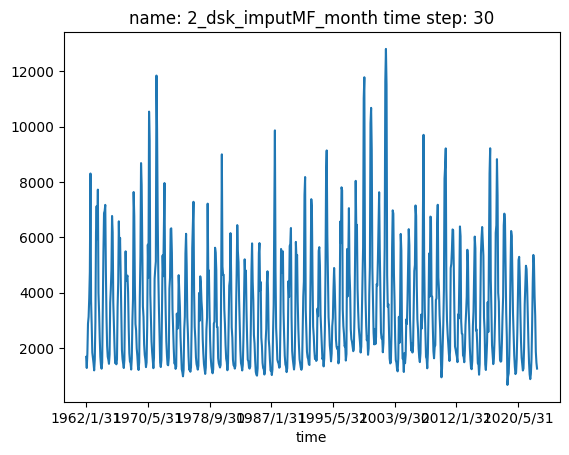

0


<ipython-input-114-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_25"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_25 (LSTM)                       │ (None, 200)                 │         164,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_25 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_25 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,001 (644.54 KB)

 Trainable params: 165,001 (644.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - MAE: 0.2380 - loss: 0.0842 - val_MAE: 0.2309 - val_loss: 0.0657
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1855 - loss: 0.0488 - val_MAE: 0.1435 - val_loss: 0.0339
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1432 - loss: 0.0387 - val_MAE: 0.1394 - val_loss: 0.0314
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.1375 - loss: 0.0332 - val_MAE: 0.1587 - val_loss: 0.0335
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.1429 - loss: 0.0296 - val_MAE: 0.1635 - val_loss: 0.0351
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1458 - loss: 0.0301 - val_MAE: 0.1428 - val_loss: 0.0286
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.1193 - loss: 0.0236 - val_MAE: 0.1252 - val_loss: 0.0248
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1122 - loss: 0.0231 - val_MAE: 0.1200 - val_loss: 0.0235
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.1061

<ipython-input-135-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


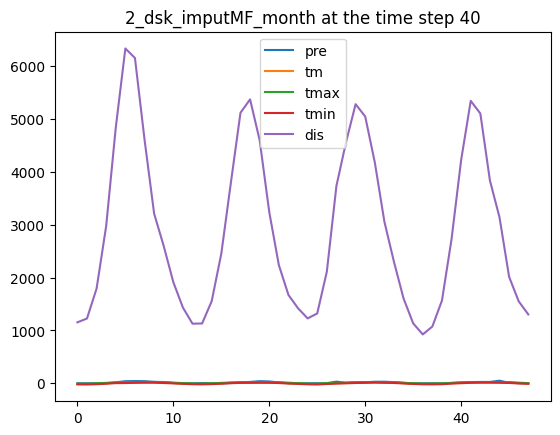

Correlation Coefficient (CC): 0.7252733177178194
Nash-Sutcliffe Efficiency (NSE): 0.49026485309824874
Kling-Gupta Efficiency (KGE): 0.6194496577291335
Root-Mean-Square Error (RMSE): 0.12755701141793152
Mean Absolute Relative Error (MARE): 0.4446370701362542
Percent Bias (PBIAS): 16.892717657852515
Coefficient of Determination (R²): 0.49026485309824874


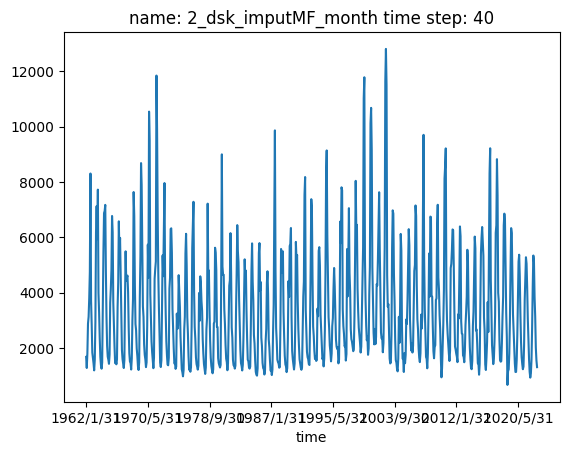

0


<ipython-input-114-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_26"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_26 (LSTM)                       │ (None, 200)                 │         164,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_26 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_26 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,001 (644.54 KB)

 Trainable params: 165,001 (644.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 80ms/step - MAE: 0.2234 - loss: 0.0748 - val_MAE: 0.2046 - val_loss: 0.0522
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1606 - loss: 0.0391 - val_MAE: 0.1387 - val_loss: 0.0337
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1377 - loss: 0.0379 - val_MAE: 0.1477 - val_loss: 0.0309
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1368 - loss: 0.0291 - val_MAE: 0.1671 - val_loss: 0.0366
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1453 - loss: 0.0312 - val_MAE: 0.1469 - val_loss: 0.0299
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1231 - loss: 0.0253 - val_MAE: 0.1251 - val_loss: 0.0249
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1069 - loss: 0.0232 - val_MAE: 0.1220 - val_loss: 0.0239
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - MAE: 0.1085 - loss: 0.0206 - val_MAE: 0.1266 - val_loss: 0.0247
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - MAE: 0.1060

<ipython-input-135-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


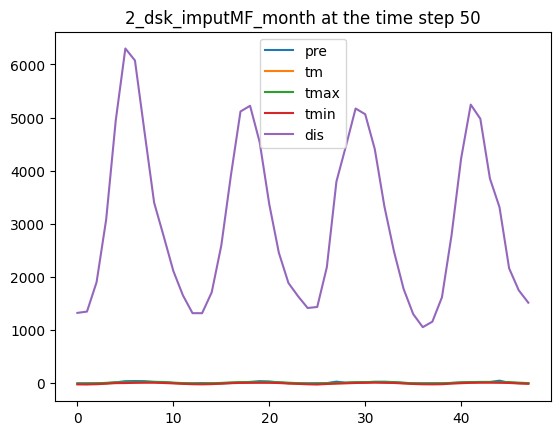

Correlation Coefficient (CC): 0.7136321193707628
Nash-Sutcliffe Efficiency (NSE): 0.4635594601380566
Kling-Gupta Efficiency (KGE): 0.5621523431764751
Root-Mean-Square Error (RMSE): 0.1312610984621352
Mean Absolute Relative Error (MARE): 0.46895868003753094
Percent Bias (PBIAS): 20.689500741406185
Coefficient of Determination (R²): 0.4635594601380566


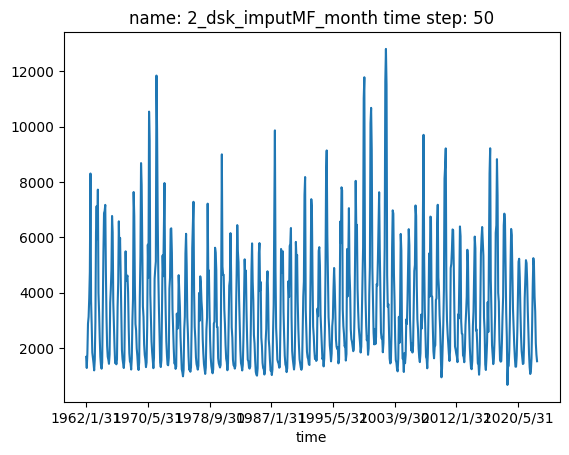

0


<ipython-input-114-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_27"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_27 (LSTM)                       │ (None, 200)                 │         164,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_27 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_27 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,001 (644.54 KB)

 Trainable params: 165,001 (644.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 86ms/step - MAE: 0.2197 - loss: 0.0737 - val_MAE: 0.2086 - val_loss: 0.0538
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1634 - loss: 0.0429 - val_MAE: 0.1450 - val_loss: 0.0377
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1500 - loss: 0.0428 - val_MAE: 0.1483 - val_loss: 0.0324
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.1422 - loss: 0.0327 - val_MAE: 0.1723 - val_loss: 0.0382
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1502 - loss: 0.0334 - val_MAE: 0.1593 - val_loss: 0.0337
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.1325 - loss: 0.0282 - val_MAE: 0.1363 - val_loss: 0.0276
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.1165 - loss: 0.0247 - val_MAE: 0.1290 - val_loss: 0.0258
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1134 - loss: 0.0235 - val_MAE: 0.1336 - val_loss: 0.0262
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1150

<ipython-input-135-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


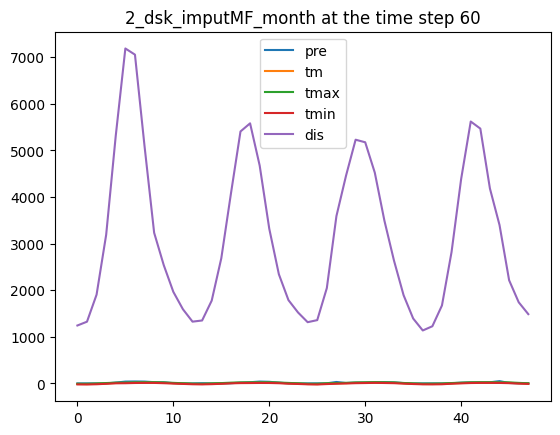

Correlation Coefficient (CC): 0.7027460244906113
Nash-Sutcliffe Efficiency (NSE): 0.43159393059587137
Kling-Gupta Efficiency (KGE): 0.5778192083501417
Root-Mean-Square Error (RMSE): 0.13592925548286272
Mean Absolute Relative Error (MARE): 0.465774297315679
Percent Bias (PBIAS): 22.394283283538854
Coefficient of Determination (R²): 0.43159393059587137


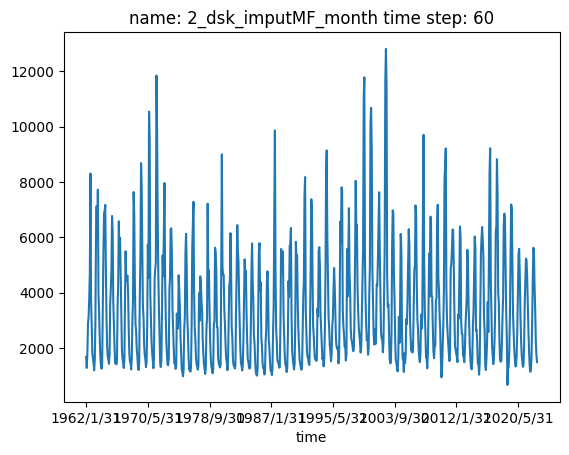

0


<ipython-input-114-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_28"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_28 (LSTM)                       │ (None, 200)                 │         164,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_28 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_28 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,001 (644.54 KB)

 Trainable params: 165,001 (644.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 87ms/step - MAE: 0.2471 - loss: 0.0998 - val_MAE: 0.2317 - val_loss: 0.0660
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - MAE: 0.1892 - loss: 0.0519 - val_MAE: 0.1499 - val_loss: 0.0365
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - MAE: 0.1575 - loss: 0.0489 - val_MAE: 0.1457 - val_loss: 0.0337
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - MAE: 0.1507 - loss: 0.0428 - val_MAE: 0.1626 - val_loss: 0.0352
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1523 - loss: 0.0366 - val_MAE: 0.1664 - val_loss: 0.0362
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1467 - loss: 0.0348 - val_MAE: 0.1452 - val_loss: 0.0298
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1346 - loss: 0.0321 - val_MAE: 0.1306 - val_loss: 0.0268
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - MAE: 0.1196 - loss: 0.0300 - val_MAE: 0.1293 - val_loss: 0.0260
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - MAE: 0.1207

<ipython-input-135-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


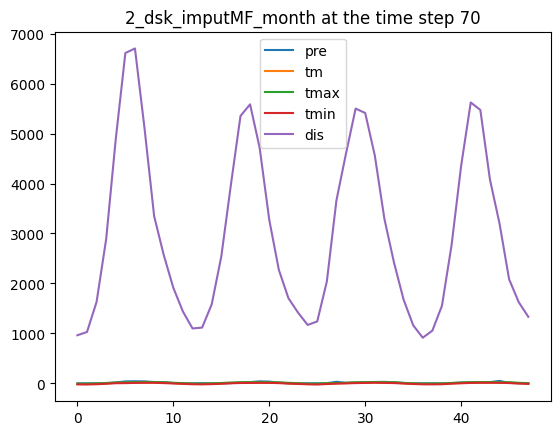

Correlation Coefficient (CC): 0.6977383399444574
Nash-Sutcliffe Efficiency (NSE): 0.44106216100761597
Kling-Gupta Efficiency (KGE): 0.6114359952701303
Root-Mean-Square Error (RMSE): 0.13548299048798138
Mean Absolute Relative Error (MARE): 0.47380456947398564
Percent Bias (PBIAS): 16.97167397026275
Coefficient of Determination (R²): 0.44106216100761597


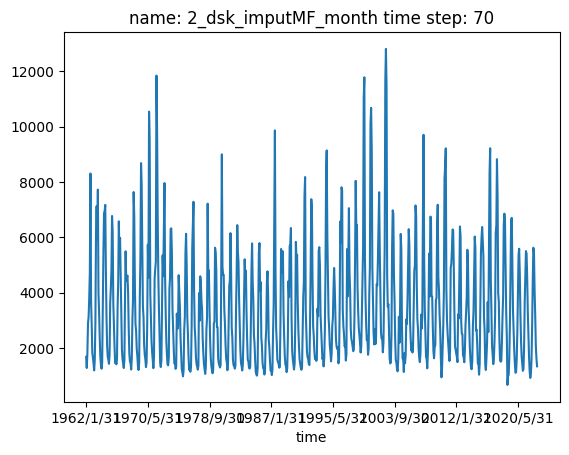

0


<ipython-input-114-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_29"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_29 (LSTM)                       │ (None, 200)                 │         164,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_29 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_29 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,001 (644.54 KB)

 Trainable params: 165,001 (644.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 88ms/step - MAE: 0.2686 - loss: 0.1164 - val_MAE: 0.2472 - val_loss: 0.0749
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - MAE: 0.2027 - loss: 0.0587 - val_MAE: 0.1502 - val_loss: 0.0361
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - MAE: 0.1594 - loss: 0.0505 - val_MAE: 0.1440 - val_loss: 0.0342
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - MAE: 0.1530 - loss: 0.0448 - val_MAE: 0.1595 - val_loss: 0.0344
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - MAE: 0.1553 - loss: 0.0383 - val_MAE: 0.1722 - val_loss: 0.0383
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - MAE: 0.1535 - loss: 0.0365 - val_MAE: 0.1597 - val_loss: 0.0339
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1450 - loss: 0.0348 - val_MAE: 0.1404 - val_loss: 0.0285
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1267 - loss: 0.0304 - val_MAE: 0.1308 - val_loss: 0.0265
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.1214

<ipython-input-135-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


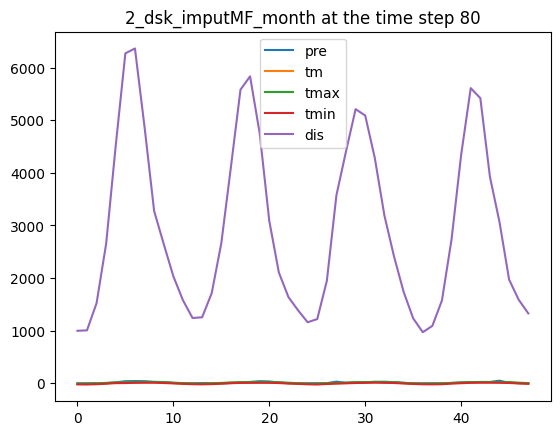

Correlation Coefficient (CC): 0.704570447928969
Nash-Sutcliffe Efficiency (NSE): 0.44758137557500355
Kling-Gupta Efficiency (KGE): 0.6019660903840208
Root-Mean-Square Error (RMSE): 0.1330155821167975
Mean Absolute Relative Error (MARE): 0.47658498293507734
Percent Bias (PBIAS): 19.11517226697345
Coefficient of Determination (R²): 0.44758137557500355


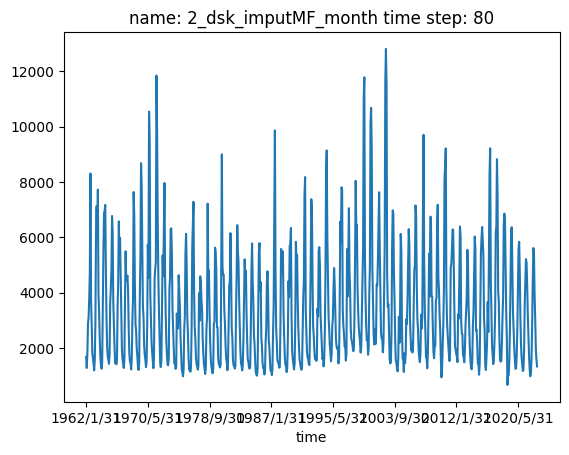

0


<ipython-input-114-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_30"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_30 (LSTM)                       │ (None, 200)                 │         164,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_30 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_30 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,001 (644.54 KB)

 Trainable params: 165,001 (644.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - MAE: 0.1729 - loss: 0.0521 - val_MAE: 0.1496 - val_loss: 0.0315
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - MAE: 0.1418 - loss: 0.0390 - val_MAE: 0.1334 - val_loss: 0.0286
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - MAE: 0.1316 - loss: 0.0316 - val_MAE: 0.1711 - val_loss: 0.0381
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - MAE: 0.1482 - loss: 0.0332 - val_MAE: 0.1428 - val_loss: 0.0287
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - MAE: 0.1270 - loss: 0.0283 - val_MAE: 0.1162 - val_loss: 0.0237
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - MAE: 0.1048 - loss: 0.0237 - val_MAE: 0.1285 - val_loss: 0.0253
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1101 - loss: 0.0217 - val_MAE: 0.1333 - val_loss: 0.0269
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - MAE: 0.1041 - loss: 0.0196 - val_MAE: 0.1041 - val_loss: 0.0210
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - MAE: 0.0925

<ipython-input-135-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


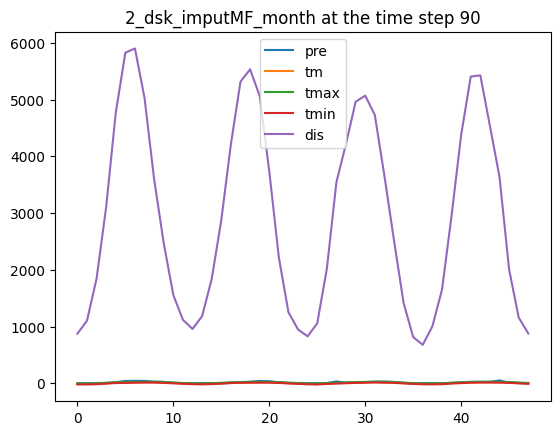

Correlation Coefficient (CC): 0.6854056273474504
Nash-Sutcliffe Efficiency (NSE): 0.4308107430894096
Kling-Gupta Efficiency (KGE): 0.5991407570489675
Root-Mean-Square Error (RMSE): 0.13591237053809943
Mean Absolute Relative Error (MARE): 0.4954986406182172
Percent Bias (PBIAS): 15.638699299063422
Coefficient of Determination (R²): 0.4308107430894096


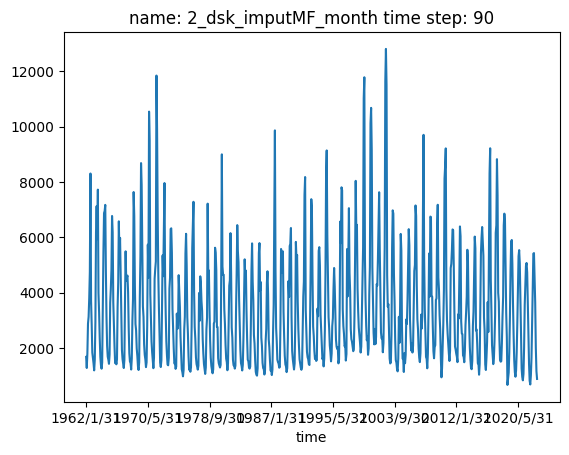

0


<ipython-input-114-059e7f0056bf>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame.drop(columns=['time'], inplace=True)
/usr/local/lib/python3.10/dist-packages/keras/src/layers/rnn/rnn.py:204: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_31"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_31 (LSTM)                       │ (None, 200)                 │         164,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_31 (Dropout)                 │ (None, 200)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_31 (Dense)                     │ (None, 1)                   │             201 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 165,001 (644.54 KB)

 Trainable params: 165,001 (644.54 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 94ms/step - MAE: 0.2114 - loss: 0.0702 - val_MAE: 0.1736 - val_loss: 0.0392
Epoch 2/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - MAE: 0.1455 - loss: 0.0360 - val_MAE: 0.1381 - val_loss: 0.0317
Epoch 3/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - MAE: 0.1407 - loss: 0.0370 - val_MAE: 0.1545 - val_loss: 0.0325
Epoch 4/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - MAE: 0.1417 - loss: 0.0319 - val_MAE: 0.1570 - val_loss: 0.0331
Epoch 5/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - MAE: 0.1328 - loss: 0.0288 - val_MAE: 0.1329 - val_loss: 0.0266
Epoch 6/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1152 - loss: 0.0264 - val_MAE: 0.1223 - val_loss: 0.0244
Epoch 7/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1073 - loss: 0.0238 - val_MAE: 0.1284 - val_loss: 0.0253
Epoch 8/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.1048 - loss: 0.0201 - val_MAE: 0.1199 - val_loss: 0.0236
Epoch 9/1000
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - MAE: 0.0931

<ipython-input-135-4f8f21420900>:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  dataFrame_full["dis"][null_index_df["Start"][i] : null_index_df["End"][i]+1]  = forecast_df['dis'][:len(forecast_values)] ###


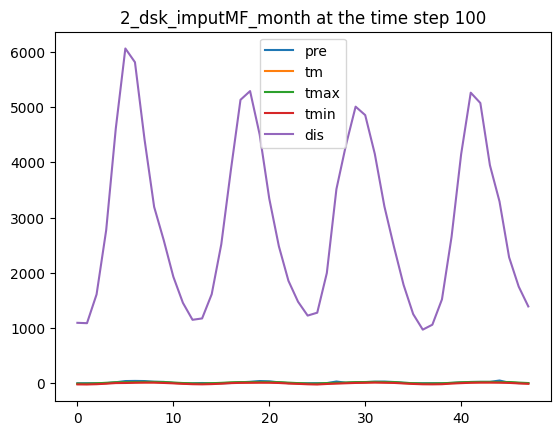

Correlation Coefficient (CC): 0.7180642093955467
Nash-Sutcliffe Efficiency (NSE): 0.4745938648731308
Kling-Gupta Efficiency (KGE): 0.5844132411068241
Root-Mean-Square Error (RMSE): 0.1313173531491928
Mean Absolute Relative Error (MARE): 0.47913752928759124
Percent Bias (PBIAS): 19.713617544781865
Coefficient of Determination (R²): 0.4745938648731308


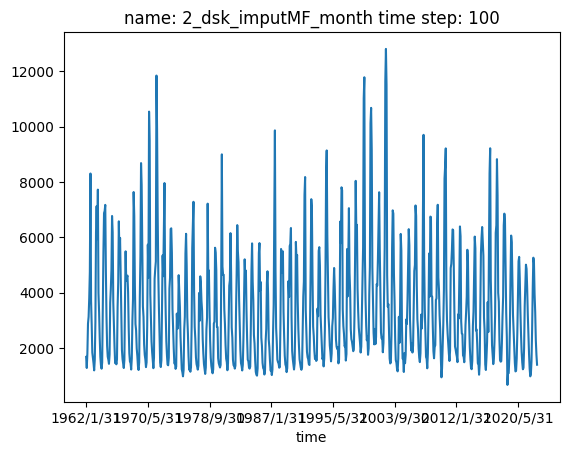

In [148]:
for time_step in range(10,101,10):
# 	i = 0
	for i in range(len(null_index_df)):
		print(i)
		intercept_data(i)
		df_scaled=scaler_data(dataFrame)
		X_train, y_train, X_test, y_test , X_forecast = split_data(df_scaled,i)
		multivariate_lstm = model_building(X_train)
		multivariate_lstm,history = model_training(multivariate_lstm, X_train, y_train, X_test, y_test)
		d=medel_predict(multivariate_lstm,  X_test, y_test)
		forecast_df  = forecast_model(multivariate_lstm,X_forecast)
		# d.missing_df(f"F:\geodata\\river_runoff_obs\\5_kq_imputMF{i}.csv")
		CC,NSE,KGE,RMSE,MARE,PBIAS,R2 = model_evaluation(d)
	dataFrame_full.index = dataFrame_full.time
	dataFrame_full['dis'].plot()
	plt.title(f"name: {name} time step: {time_step}")
	plt.savefig(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_dataFrame_full_plot.jpg")
	plt.show()

dataFrame_full.to_csv(f"/content/drive/MyDrive/river_runoff_obs/{name}_{time_step}_interpolated.csv")

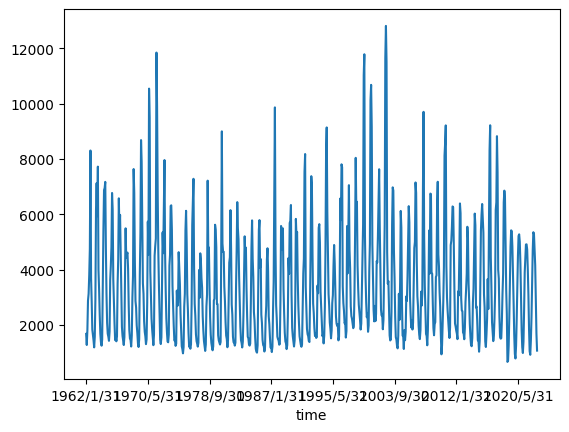

In [145]:
dataFrame_full.index = dataFrame_full.time
dataFrame_full['dis'].plot()
plt.show

In [144]:
dataFrame_full.index = dataFrame_full.time